<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/deep-learning/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ex3 - Linear Regression

## Imports

In [ ]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

## Load data

Define the path to the file containing the data

In [ ]:
datafile = "lausanne-appart.csv"

Read the data

In [ ]:
dataset = pd.read_csv(datafile)

Display first rows

In [ ]:
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [ ]:
# get numpy arrays from panda objects
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values
print(type(rent_price))
print(rent_price.shape, living_area.shape)

<class 'numpy.ndarray'>
(201,) (201,)


## Part 1 - Visualize the data

a) Plot a histogram to visualize the distribution of the renting price

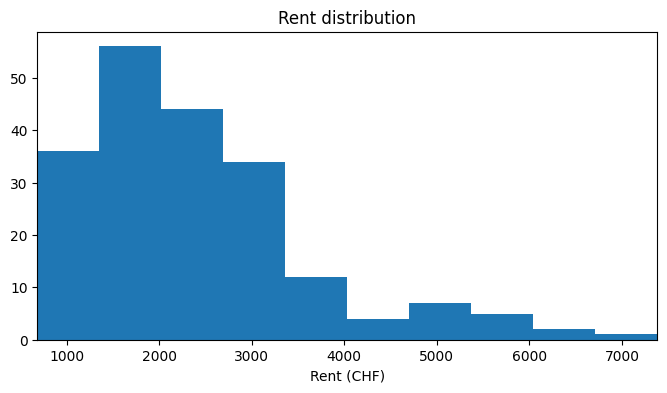

In [ ]:
plt.figure(1, figsize=(8, 4))
plt.hist(rent_price)
plt.xlabel("Rent (CHF)")
plt.title("Rent distribution")
plt.xlim(np.min(rent_price), np.max(rent_price))
plt.show()

b) Plot a histogram to visualize the distribution of the living area

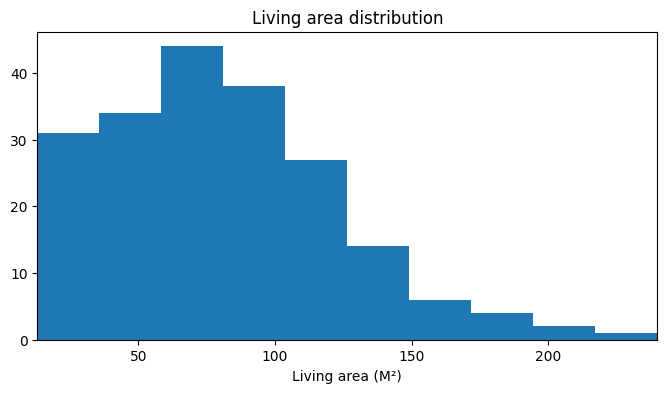

In [ ]:
# Your code here
plt.figure(1, figsize=(8, 4))
plt.hist(living_area)
plt.xlabel("Living area (M²)")
plt.title("Living area distribution")
plt.xlim(np.min(living_area), np.max(living_area))
plt.show()

c) Plot a scatter plot of renting price as a function of living area

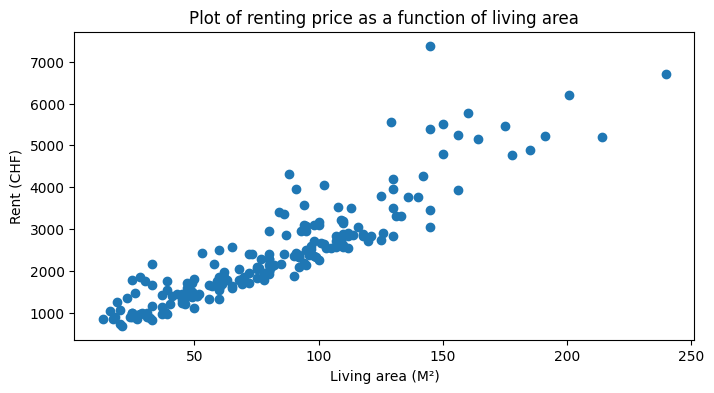

In [ ]:
# Your code here
plt.figure(1, figsize=(8, 4))
plt.scatter(living_area, rent_price)
plt.xlabel("Living area (M²)")
plt.ylabel("Rent (CHF)")
plt.title("Plot of renting price as a function of living area")
plt.show()

## Part 2 - Normal equations for linear regression - using numpy arrays

a) Implement the closed form solution to this problem using the following normal equation:

<div><div style="display: table-cell; width: 100%;"><center>$\theta = (X^{T}X)^{-1}X^{T}\vec{y}$</center></div><div style="display: table-cell; width: 100%;">$(3)$</div></div>

Assuming $x$ is the living area and $y$ is the renting price. Use `numpy` for the vector operations. Plot the computed line on top of the scatter plot of Part 1.

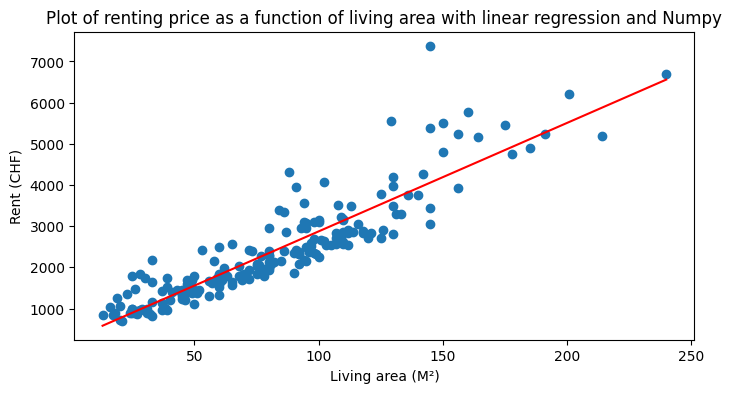

In [ ]:
#######################################################################
# TODO:                                                               #
# Perform the following computation                                   #
#  - get N, the number of samples                                     #
#  - compose X with the 1st column full of 1.0 and the 2nd column     #
#    with the living area (hint: have a look to no.ones() and         #
#    np.column_stack()                                                #
#  - get y as the rent prices                                         #
#  - compute the theta (hint: matrix A to matrix B multiplication can #
#    be done with A.dot(B))                                           #
#  - plot the line (hint: compute a set of x points linearly spaced   #
#    and, with the thetas, compute the corresponding y values)        #
#######################################################################
x = dataset['living_area']
y = dataset['rent_price']

N = dataset.shape[0]
X = np.column_stack((np.ones(len(dataset)), x))

theta = np.linalg.inv(X.T @ X) @ X.T @ y # theta = (X^T X)⁻¹X^Ty

x_line = np.linspace(x.min(), x.max(), 100) # linearly spaced
y_line = theta[0] + theta[1] * x_line

plt.figure(1, figsize=(8, 4))
plt.plot(x_line, y_line, c = 'red') # the red line fits to the datas of the dataset
plt.scatter(living_area, rent_price)
plt.xlabel("Living area (M²)")
plt.ylabel("Rent (CHF)")
plt.title("Plot of renting price as a function of living area with linear regression and Numpy")
plt.show()

#######################################################################
#                         END OF YOUR CODE                            #
#######################################################################

b) Compute the MSE loss according to the following equation:

<div><div style="display: table-cell; width: 100%;"><center>$J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (h_{\theta}(\mathbf{x}_{n}) - y_{n})^{2}$</center></div><div style="display: table-cell; width: 100%;">$(2)$</div></div>

In [ ]:
#######################################################################
# TODO:                                                               #
#  - define a function h_theta(x, theta_0, theta_1) to compute the    #
#    the hypothesised values of y (the "y_hat")                       #
#  - define a function mse_loss(x, y, y_hat)                          #
#  - use both functions to compute the MSE loss on the dataset        #
#######################################################################
def h_theta(x, theta_0, theta_1):
    return theta_0 + theta_1 * x

def mse_loss(x, y, y_hat):
    return (1/(2*N)) * np.sum((y - y_hat)**2)

y_hat = h_theta(x, theta[0], theta[1])
MSE = mse_loss(x, y, y_hat)
print("MSE loss on the dataset with Numpy: ", MSE)

#######################################################################
#                         END OF YOUR CODE                            #
#######################################################################

MSE loss on the dataset with Numpy:  138034.95779787414


## Part 3 - Normal equations for linear regression - using pytorch tensors

Redo the part 2, this time using pytorch tensors.

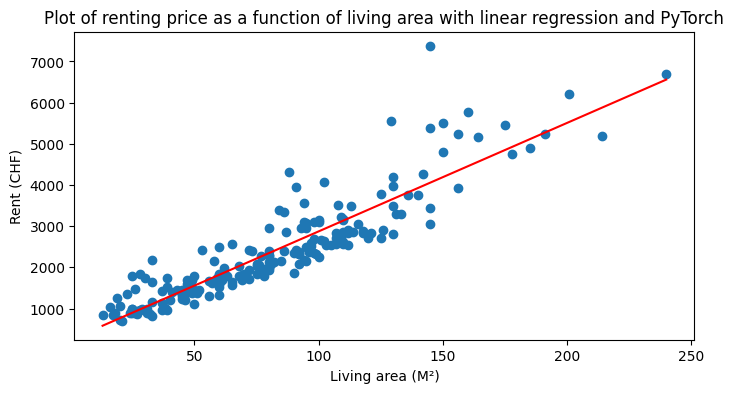

MSE loss on the dataset with PyTorch :  tensor(138034.9531)


In [ ]:
#######################################################################
# TODO:                                                               #
# Perform the following computation                                   #
#  - in a similar way as in the previous part 2, compute theta0 and   #
#    theta1, plot the computed line                                   #
#  - compute the loss J with these new values of theta0 and theta1,   #
#    for that you may use mse_loss() function defined abouve          #
#######################################################################
import torch

x = torch.tensor(dataset['living_area'], dtype=torch.float32)
y = torch.tensor(dataset['rent_price'], dtype=torch.float32)

X = torch.column_stack((torch.ones(N), x))
theta = torch.linalg.inv(X.T @ X) @ X.T @ y # theta = (X^T X)⁻¹X^Ty

x_line = torch.linspace(x.min(), x.max(), 100) # linearly spaced
y_line = theta[0] + theta[1] * x_line

plt.figure(1, figsize=(8, 4))
plt.plot(x_line, y_line, c = 'red') # the red line fits to the datas of the dataset
plt.scatter(living_area, rent_price)
plt.xlabel("Living area (M²)")
plt.ylabel("Rent (CHF)")
plt.title("Plot of renting price as a function of living area with linear regression and PyTorch")
plt.show()

y_hat = h_theta(x, theta[0], theta[1])

def mse_loss_torch(x, y, y_hat):
    return (1/(2*N)) * torch.sum((y - y_hat)**2)
MSE_torch = mse_loss_torch(x, y, y_hat)
print("MSE loss on the dataset with PyTorch : ", MSE_torch)

#######################################################################
#                         END OF YOUR CODE                            #
#######################################################################